In [2]:
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import ROOT

In [5]:
file_TTG = '/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/TTG1Jets_text.root'
factory = NanoEventsFactory.from_root(
    f"{file_TTG}:Events",
    schemaclass=NanoAODSchema,
)
events_TTG = factory.events()

In [6]:
file_TT2L = '/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/TTto2L2Nu_text.root'
factory = NanoEventsFactory.from_root(
    f"{file_TT2L}:Events",
    schemaclass=NanoAODSchema,
)
events_TT2L = factory.events()

In [7]:
events_TTG.fields

['LHEPdfWeight',
 'genTtbarId',
 'GenPart',
 'TrigObj',
 'PV',
 'GenJet',
 'MC',
 'boostedTau',
 'TrackGenJetAK4',
 'TauSpinner',
 'PFCand',
 'GenDressedLepton',
 'SoftActivityJetHT5',
 'L1Reco',
 'PFMET',
 'DST',
 'LHEPart',
 'SV',
 'RawPuppiMET',
 'TauProd',
 'LHEReweightingWeight',
 'SoftActivityJetNjets10',
 'Flag',
 'DeepMETResolutionTune',
 'Electron',
 'L1simulation',
 'LHEWeight',
 'genWeight',
 'SoftActivityJet',
 'SoftActivityJetHT2',
 'CorrT1METJet',
 'LHE',
 'GenProton',
 'SoftActivityJetHT10',
 'FsrPhoton',
 'orbitNumber',
 'Muon',
 'HLT',
 'Tau',
 'TrkMET',
 'FiducialMET',
 'OtherPV',
 'GenMET',
 'RawPFMET',
 'HLTriggerFinalPath',
 'FatJetPFCand',
 'BeamSpot',
 'PuppiMET',
 'L1',
 'GenJetAK8',
 'PSWeight',
 'Pileup',
 'LowPtElectron',
 'SubJet',
 'SubGenJetAK8',
 'DeepMETResponseTune',
 'run',
 'SoftActivityJetNjets5',
 'SoftActivityJetNjets2',
 'GenVtx',
 'FatJet',
 'Dataset',
 'LHEScaleWeight',
 'HLTriggerFirstPath',
 'HTXS',
 'IsoTrack',
 'Jet',
 'PVBS',
 'CaloMET',
 '

In [12]:
events_TT2L.GenPart.pdgId[events_TT2L.GenPart.pdgId == 22]

<Array [[], [], ..., [], [22, 22, 22, 22]] type='603450 * var * int32[param...'>

In [22]:
gen_pho = events_TT2L.GenPart[(events_TT2L.GenPart.pdgId == 22) & (events_TT2L.GenPart.status == 1) & (events_TT2L.GenPart.pt > 10)]
gen_pho_TTG = events_TTG.GenPart[(events_TTG.GenPart.pdgId == 22) & (events_TTG.GenPart.status == 1) & (events_TTG.GenPart.pt > 10)]

In [17]:
gen_pho.pdgId

<Array [[], [], [], ..., [], [], [22, 22, 22]] type='603450 * var * int32[p...'>

In [23]:
mother_part = events_TT2L.GenPart[gen_pho.genPartIdxMother]
mother_part_TTG = events_TTG.GenPart[gen_pho_TTG.genPartIdxMother]

In [20]:
np.unique(ak.flatten(mother_part.pdgId))

<Array [-20433, -20213, -5314, ..., 20443, 100443, 9000221] type='106 * int32'>

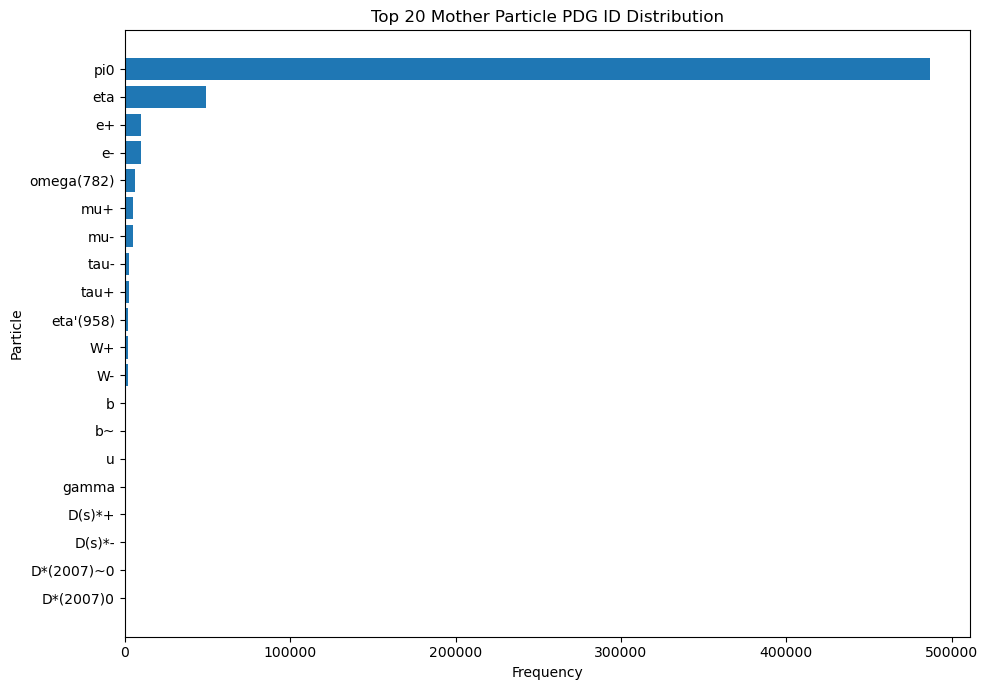

In [21]:
from particle import Particle

# Flatten PDG IDs
pdg_ids = ak.to_numpy(ak.flatten(mother_part.pdgId))

# Count frequencies
unique, counts = np.unique(pdg_ids, return_counts=True)

# Convert PDG ID → particle name
names = []
for pid in unique:
    try:
        names.append(Particle.from_pdgid(pid).name)
    except:
        names.append(f"unknown({pid})")

# Sort by frequency (descending)
idx = np.argsort(counts)[::-1]
unique = unique[idx]
counts = counts[idx]
names  = [names[i] for i in idx]

# Plot (top 20 for readability)
N = 20
plt.figure(figsize=(10,7))
plt.barh(names[:N], counts[:N])
plt.xlabel("Frequency")
plt.ylabel("Particle")
plt.title("Top 20 Mother Particle PDG ID Distribution")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

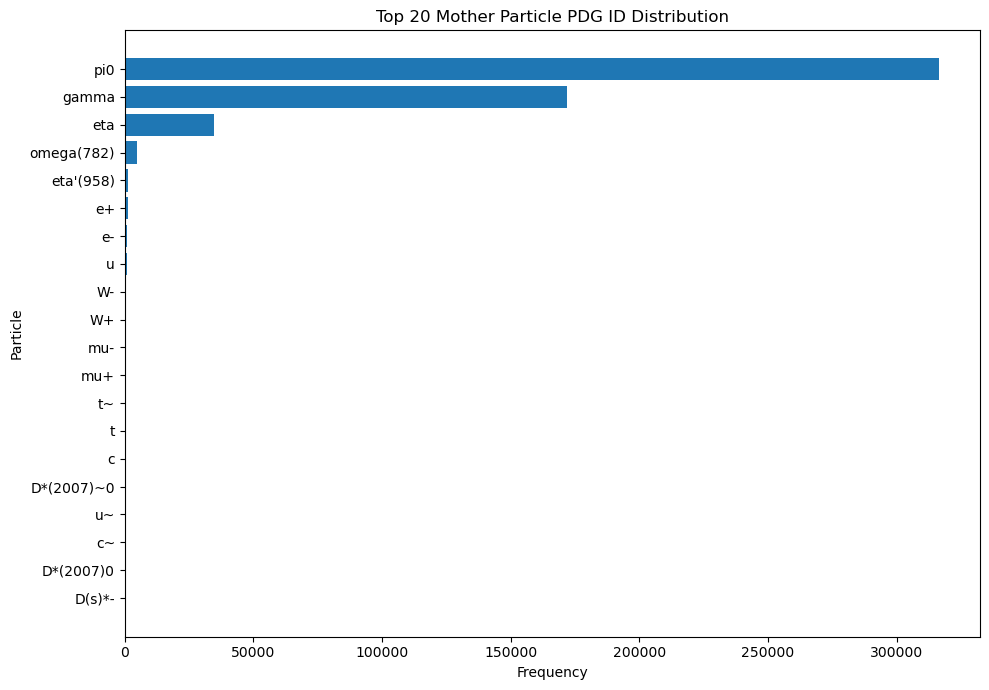

In [24]:
# Flatten PDG IDs
pdg_ids = ak.to_numpy(ak.flatten(mother_part_TTG.pdgId))

# Count frequencies
unique, counts = np.unique(pdg_ids, return_counts=True)

# Convert PDG ID → particle name
names = []
for pid in unique:
    try:
        names.append(Particle.from_pdgid(pid).name)
    except:
        names.append(f"unknown({pid})")

# Sort by frequency (descending)
idx = np.argsort(counts)[::-1]
unique = unique[idx]
counts = counts[idx]
names  = [names[i] for i in idx]

# Plot (top 20 for readability)
N = 20
plt.figure(figsize=(10,7))
plt.barh(names[:N], counts[:N])
plt.xlabel("Frequency")
plt.ylabel("Particle")
plt.title("Top 20 Mother Particle PDG ID Distribution")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [30]:
Mother_pho = mother_part[mother_part.pdgId == 22]

In [31]:
Mother_pho.pdgId[ak.num(Mother_pho.pdgId) > 0]

<Array [[22], [22, 22], [22], ..., [22], [22]] type='434 * var * int32[para...'>

In [32]:
Mother_pho.pt[ak.num(Mother_pho.pt) > 0]

<Array [[11.4], [11.8, 11.8], ..., [10.2]] type='434 * var * float32[parame...'>

In [35]:
true_mother = events_TT2L.GenPart[Mother_pho.genPartIdxMother]

In [38]:
np.unique(ak.flatten(true_mother.pdgId[ak.num(true_mother.pdgId) > 0]))

<Array [-20213, -531, -213, 111, ..., 331, 333, 423, 511] type='10 * int32'>